[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

* Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
* Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
* [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
* [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [1]:
%%capture --no-stderr
%pip install --quiet -U langchain_openai langchain_core langgraph

## Messages

Chat models can use [messages](https://docs.langchain.com/oss/python/langchain/messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [1]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Lance"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the US.", name="Lance"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Lance

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Lance

I want to learn about the best place to see Orcas in the US.


## Chat Models

Chat models use a sequence of messages as input and support message types, as discussed above.

There are [many](https://docs.langchain.com/oss/python/integrations/chat) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

In [3]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [2]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model = "deepseek-v3.1:671b-cloud")
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [3]:
result

AIMessage(content='Of course! The Pacific Northwest, specifically the waters around Washington State and Alaska, is arguably the best place in the U.S. to see orcas. However, the "best" place can depend on what kind of experience you\'re looking for and what time of year you plan to visit.\n\nHere’s a breakdown of the top locations and what makes each one special:\n\n### 1. San Juan Islands, Washington (The Classic Experience)\nThis is the most famous and reliable spot for viewing the **Southern Resident killer whales**. These fish-eating orcas are a unique population that is critically endangered, making sightings of them particularly special.\n\n*   **Best Time to Go:** **Mid-April to October**, with peak season in June through September.\n*   **Why it\'s great:** The islands are a core part of the orcas\' summer habitat as they follow the Chinook salmon runs. The scenery is stunning, with a high probability of sightings.\n*   **How to see them:**\n    *   **Guided Whale Watching Tou

In [4]:
result.response_metadata

{'model': 'deepseek-v3.1:671b',
 'created_at': '2026-04-03T03:52:45.17132728Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 13996930149,
 'load_duration': None,
 'prompt_eval_count': 51,
 'prompt_eval_duration': None,
 'eval_count': 973,
 'eval_duration': None,
 'logprobs': None,
 'model_name': 'deepseek-v3.1:671b',
 'model_provider': 'ollama'}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://docs.langchain.com/oss/python/integrations/chat) and [tool calling interface](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [5]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [6]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 2 multiplied by 3", name="Lance")])

In [8]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': '83f9c199-4cae-4dca-be80-b0fbf04d7d5b',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [9]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem! 

As we discussed, each node will return a new value for our state key `messages`.

But, this new value will overwrite the prior `messages` value!
 
As our graph runs, we want to **append** messages to our `messages` state key.
 
We can use [reducer functions](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers) to address this.

Reducers specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.
 
But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [10]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built  [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [11]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [12]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Lance")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='bc29a4cf-32e3-4401-a1ac-e78fadd892f5', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Lance', id='e68402b1-f776-4943-814f-132e1834e877'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='6853781b-c531-4009-a895-f4560320d4d8', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

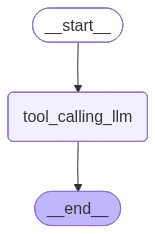

In [13]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
# from langgraph.graph import StateGraph, START, END, MessagesState
# from langchain_ollama import ChatOllama
# from langchain_core.messages import HumanMessage
from constants import MODEL

# Define llm
llm = ChatOllama(model=MODEL)

# Define the state class
class MessagesState(MessagesState):
    pass

# Define tools
def add(a: int, b : int) -> int:
    """
    This function takes 2 int arguments, adds them up and returns the result
    args:
        - a: first int
        - b: first int
    """
    return a + b

# Bind tools to llm
llm = llm.bind_tools([add, multiply])

# Define the node
def llm_func(state):
    # messages = state["messages"]
    # response = llm.invoke(messages)
    # return {"messages": messages + [response]}
    return {"messages": [llm.invoke(state["messages"])]}


# Build graph
builder = StateGraph(MessagesState)
builder.add_node("llm", llm_func)
builder.add_edge(START, "llm")
builder.add_edge("llm", END)
graph = builder.compile()

messages = graph.invoke({"messages": [HumanMessage(content="What can you do? Can you multiply 2 and 3 for me?")]})

print(messages)
for m in messages['messages']:
    m.pretty_print()

{'messages': [HumanMessage(content='What can you do? Can you multiply 2 and 3 for me?', additional_kwargs={}, response_metadata={}, id='5c9d9589-d6f2-40f6-b958-50938242325f'), AIMessage(content='I can help you with basic arithmetic operations! I have two tools available:\n\n1. **Add** - I can add two integers together\n2. **Multiply** - I can multiply two integers together\n\nNow let me multiply 2 and 3 for you:', additional_kwargs={}, response_metadata={'model': 'minimax-m2.5', 'created_at': '2026-04-03T04:25:32.959568455Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2005109644, 'load_duration': None, 'prompt_eval_count': 277, 'prompt_eval_duration': None, 'eval_count': 188, 'eval_duration': None, 'logprobs': None, 'model_name': 'minimax-m2.5', 'model_provider': 'ollama'}, id='lc_run--019d5196-cd38-7f80-ab78-a3cec98a8120-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '1392f6f5-e7d0-445b-ad2e-ccbeda54bfd1', 'type': 'tool_call'}], invalid_tool_calls=[],

If we pass in `Hello!`, the LLM responds without any tool calls.

In [20]:
messages = graph.invoke({"messages": HumanMessage(content="Hello!")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello!
================================== Ai Message ==================================

Hello there! How can I help you today? I have some math tools available if you need to do any calculations - I can add numbers together or multiply them. Just let me know what you need!


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [21]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 2 and 3")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (bd356a02-a259-4b7f-b63e-b537fa0c54f9)
 Call ID: bd356a02-a259-4b7f-b63e-b537fa0c54f9
  Args:
    a: 2
    b: 3
